## Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

## Data Collection and Data Processing

In [5]:
df = pd.read_csv('sonar_data.csv', header=None)

In [6]:
print("First 5 Rows of the Dataset\n")
df.head()

First 5 Rows of the Dataset



,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [7]:
#number of rows and cols
df.shape

(208, 61)

In [8]:
print("Statistical Summary \n")
df.describe()

Statistical Summary 



,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


In [9]:
df[60].value_counts()

60
M    111
R     97
Name: count, dtype: int64

M --> Mine

R --> Rock

In [10]:
df.groupby(60).mean()

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
60,,,,,,,,,,,,,,,,,,,,,
M,0.034989,0.045544,0.050720,0.064768,0.086715,0.111864,0.128359,0.149832,0.213492,0.251022,...,0.019352,0.016014,0.011643,0.012185,0.009923,0.008914,0.007825,0.009060,0.008695,0.006930
R,0.022498,0.030303,0.035951,0.041447,0.062028,0.096224,0.114180,0.117596,0.137392,0.159325,...,0.012311,0.010453,0.009640,0.009518,0.008567,0.007430,0.007814,0.006677,0.007078,0.006024


In [11]:
#separating Data and Labels
X = df.drop(columns=60, axis=1)  # --> data
Y = df[60]                        # --> labels

In [12]:
X.head()
Y.head()

0    R
1    R
2    R
3    R
4    R
Name: 60, dtype: object

## Training and Test Data

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.1, stratify=Y, random_state=1
)

In [14]:
print(X.shape, X_train.shape, X_test.shape)

(208, 60) (187, 60) (21, 60)


## Model Training — Comparing Several Models

Instead of committing to a single algorithm right away, we compare a few common classifiers
using **5-fold stratified cross-validation** on the training data. This gives a much more
reliable accuracy estimate than a single train/test split, especially with only ~200 rows total.

Each model is wrapped in a `Pipeline` with `StandardScaler`, since scaling helps
distance-based (KNN) and margin-based (SVM) models, and is good practice generally.

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (RBF kernel)": SVC(kernel="rbf"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=1),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
cv_results = {}

for name, clf in models.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("model", clf)])
    scores = cross_val_score(pipe, X_train, Y_train, cv=cv, scoring="accuracy")
    cv_results[name] = scores
    print(f"{name:22s}  mean={scores.mean():.3f}  std={scores.std():.3f}")

Logistic Regression     mean=0.769  std=0.057
SVM (RBF kernel)        mean=0.818  std=0.033
Random Forest           mean=0.807  std=0.049
K-Nearest Neighbors     mean=0.786  std=0.028


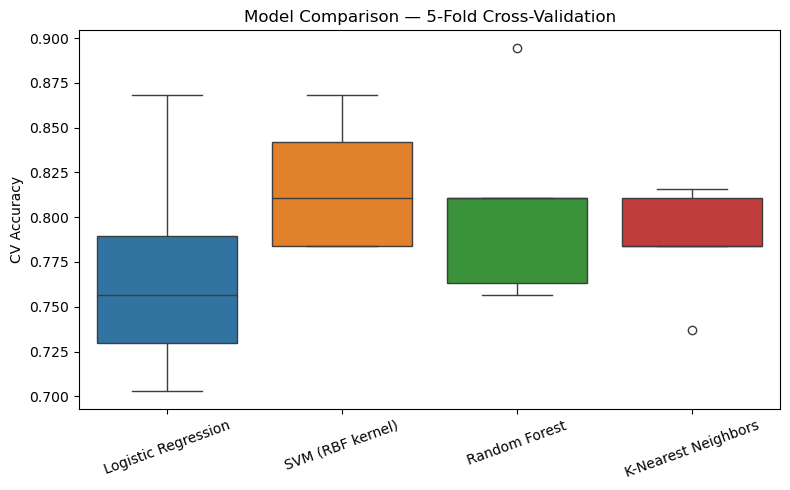

In [16]:
# Visualize cross-validation results
plt.figure(figsize=(8, 5))
sns.boxplot(data=list(cv_results.values()))
plt.xticks(range(len(cv_results)), list(cv_results.keys()), rotation=20)
plt.ylabel("CV Accuracy")
plt.title("Model Comparison — 5-Fold Cross-Validation")
plt.tight_layout()
plt.show()

## Final Model

Based on the cross-validation results above, SVM (RBF kernel) is the best-performing model 

In [17]:
best_model_name = "SVM (RBF kernel)" 

final_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", models[best_model_name]),
])

final_pipe.fit(X_train, Y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


## Model Evaluation

In [18]:
#accuracy on training data
X_train_prediction = final_pipe.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print("Accuracy on training Data:", training_data_accuracy)

Accuracy on training Data: 0.9786096256684492


In [19]:
#accuracy on test data
X_test_prediction = final_pipe.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print("Accuracy on test Data:", test_data_accuracy)

Accuracy on test Data: 0.8571428571428571


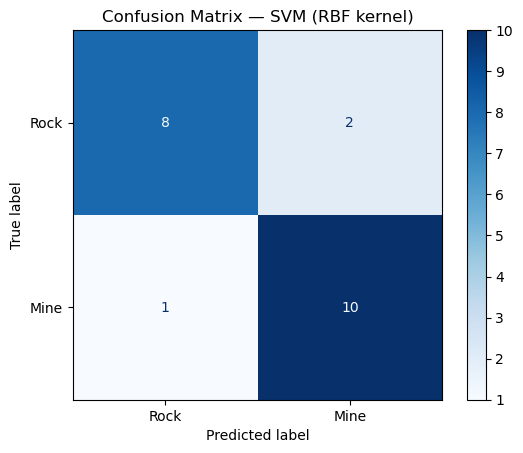

              precision    recall  f1-score   support

        Rock       0.83      0.91      0.87        11
        Mine       0.89      0.80      0.84        10

    accuracy                           0.86        21
   macro avg       0.86      0.85      0.86        21
weighted avg       0.86      0.86      0.86        21



In [20]:
# Confusion matrix + full classification report
cm = confusion_matrix(Y_test, X_test_prediction, labels=["R", "M"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rock", "Mine"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

print(classification_report(Y_test, X_test_prediction, target_names=["Rock", "Mine"]))

## Making a Predictive System

In [21]:
input_data = (0.0368,0.0403,0.0317,0.0293,0.0820,0.1342,0.1161,0.0663,0.0155,0.0506,0.0906,0.2545,0.1464,0.1272,0.1223,0.1669,0.1424,0.1285,0.1857,0.1136,0.2069,0.0219,0.2400,0.2547,0.0240,0.1923,0.4753,0.7003,0.6825,0.6443,0.7063,0.5373,0.6601,0.8708,0.9518,0.9605,0.7712,0.6772,0.6431,0.6720,0.6035,0.5155,0.3802,0.2278,0.1522,0.0801,0.0804,0.0752,0.0566,0.0175,0.0058,0.0091,0.0160,0.0160,0.0081,0.0070,0.0135,0.0067,0.0078,0.0068)

# changing the input_data type to numpy array
input_data_as_np_array = np.asarray(input_data)

# reshape the numpy array as we are predicting for one instance
input_data_reshaped = input_data_as_np_array.reshape(1, -1)

# Note: final_pipe already includes the scaler, so we pass raw values straight in.
prediction = final_pipe.predict(input_data_reshaped)

print(prediction)

if prediction[0] == "R":
    print("The Object is a Rock")
else:
    print("The Object is a Mine")

['R']
The Object is a Rock
